In [18]:
import os
import pandas as pd
from dataset import load_dataset
from regression.random_forest_regression import RandomForestRegressorModel
import joblib
from regression.probabilistic_rf_scoring import fit_rank_pdfs_loglik
from regression.probabilistic_rf_scoring import plot_ranked_pdfs
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [11]:
TARGET_COL = "trq_target"
FEUTURE=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/random_forest_regressor/model_target/"
MODEL_PATH="random_forest_model_target.pkl"
METRIC_TRAIN="metric_train.csv"
METRIC_TEST="metric_test.csv"

In [12]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)

X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test = test_df[TARGET_COL].values

In [4]:
rf_model = RandomForestRegressorModel(
    n_estimators=500,
    min_samples_leaf=5
)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    rf_model=joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
    rf_model.fit(X_train, y_train)
    joblib.dump(rf_model, OUTPUT_PATH + MODEL_PATH)

In [5]:
metric_train=rf_model.evaluate(X_train, y_train,"train")
df_metric_train = pd.DataFrame([metric_train])
df_metric_train.to_csv(OUTPUT_PATH+METRIC_TRAIN, index=False)

metric_validate=rf_model.evaluate(X_test, y_test,"test")
df_metric_test = pd.DataFrame([metric_validate])
df_metric_test.to_csv(OUTPUT_PATH+METRIC_TEST, index=False)


Metrics on train
MAE  : 0.103594
RMSE : 0.182683
R²   : 0.999834

Metrics on test
MAE  : 0.144856
RMSE : 0.252976
R²   : 0.999683


In [13]:
row = test_df.iloc[332]
torque_measured=row['trq_measured']
x0 = row[FEUTURE].to_numpy().reshape(1, -1)
y_true = (torque_measured/row[TARGET_COL]-1)*100

tree_preds = rf_model.predict_trees(x0)
mean_trq_margin_pred=np.mean(tree_preds)

In [14]:
trq_margin_pred = 100.0 * (torque_measured / tree_preds - 1)
samples_global = trq_margin_pred.reshape(-1).astype(np.float64)
mean_trq_margin_pred=np.mean(samples_global)

In [15]:
ranking,best =  fit_rank_pdfs_loglik(samples_global)


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-797.29
02) laplace      | loglik=-799.94
03) logistic     | loglik=-805.20
04) lognorm      | loglik=-818.97
05) erlang       | loglik=-821.30
06) gamma        | loglik=-821.30
07) beta         | loglik=-821.62
08) nakagami     | loglik=-827.78
09) betaprime    | loglik=-836.20
10) norm         | loglik=-837.36
11) cauchy       | loglik=-841.91
12) gumbel_r     | loglik=-842.50
13) weibull_min  | loglik=-861.65
14) rayleigh     | loglik=-963.60
15) expon        | loglik=-1242.57
16) pareto       | loglik=-1242.57
17) powerlaw     | loglik=-1275.21
18) uniform      | loglik=-1283.37
19) chi2         | loglik=-1329.30
20) f            | loglik=-1660.74


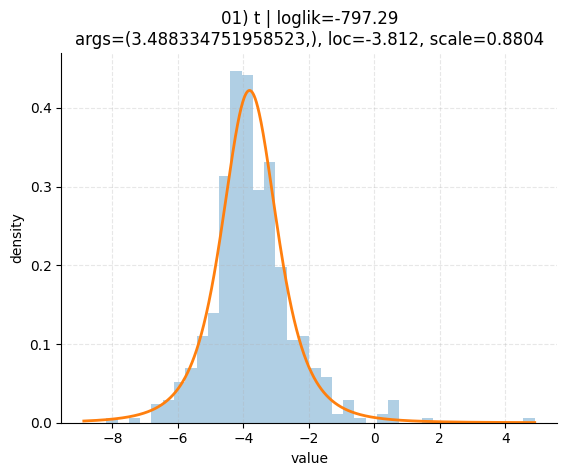

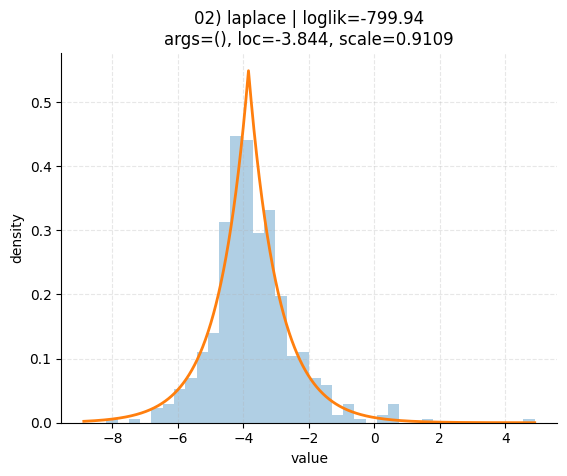

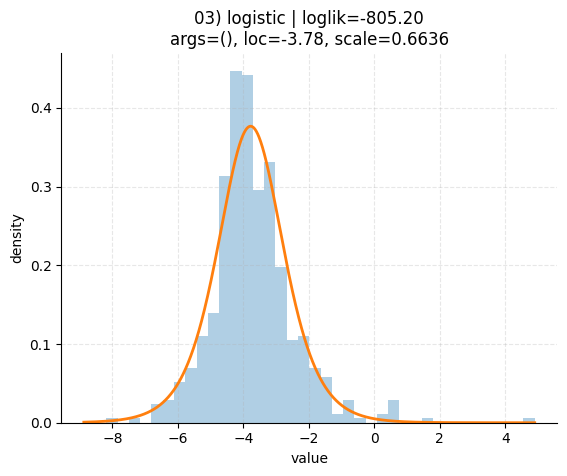

In [19]:
plot_ranked_pdfs(ranking,samples_global)

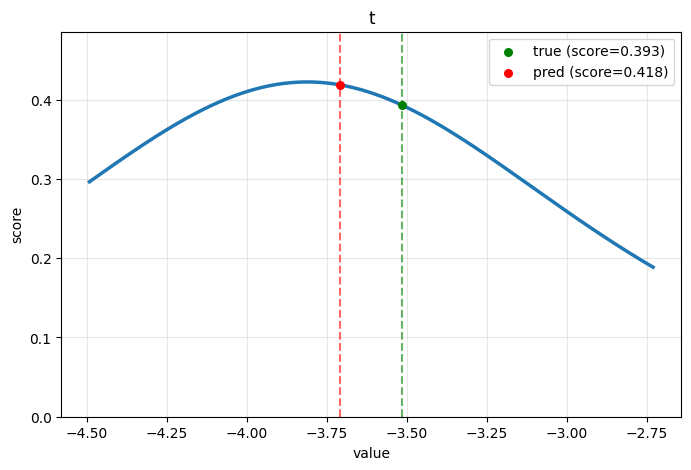

{'pdf_type': 't',
 'true_target': -3.515185584473368,
 'prediction': -3.708252660837936,
 'score_true': 0.39281341885448107,
 'score_pred': 0.4184079498417894,
 'x_range': (-4.492128472291299, -2.731309773020005)}

In [17]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],y_true,mean_trq_margin_pred)